In [1]:
import csv
import sys

csv.field_size_limit(sys.maxsize)

with open("Fixed_news_dataset.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    data = list(reader)

    # Lấy danh sách field names (tên cột)
    fieldnames = reader.fieldnames
    
    

In [2]:
print(f"Tổng số mẫu: {len(data)}")
# print(data[0])
# In ra tất cả các field
print("Các field trong CSV:")
for field in fieldnames:
    print(field)

Tổng số mẫu: 184539
Các field trong CSV:
Unnamed: 0.1
Unnamed: 0
id
author
content
picture_count
processed
source
title
topic
url
crawled_at


In [3]:
topics = []
for i in data:
    if i["topic"] not in topics:
        topics.append(i["topic"])
        print(i["topic"])

Pháp luật
Sức khỏe - Đời sống
Giáo dục
Thế giới
Thời sự
Văn hóa - Giải trí
Thể thao
Xã hội
Bất động sản
Công nghệ
Kinh tế
Kinh doanh - Tài chính
Bạn đọc
Chính trị
Quốc phòng
Xe
Pháp luật


In [4]:
economical_topics = {"Bất động sản", "Kinh tế", "Kinh doanh - Tài chính"}

for i in data:
    i["label"] = 1 if i["topic"] in economical_topics else 0

In [5]:
print(data[0])

{'Unnamed: 0.1': '0', 'Unnamed: 0': '0', 'id': '218270', 'author': '', 'content': "Chiều 31/7, Công an tỉnh Thừa Thiên - Huế thông ban đầu vụ nổ súng,cướp tiệm vàng chợ Đông Ba nằm đường Trần Hưng Đạo (TP Huế, tỉnh Thừa Thiên - Huế). Thông Sài Gòn Giải Phóng, 12h30' 31/7, đối tượng sử dụng súng AK bất ngờ xông tiệm vàng Hoàng Đức Thái Lợi (phía chợ Đông Ba) nổ súng thiên liên tiếp uy hiếp chủ tiệm cướp vàng. Sau đó, đối tượng vàng cướp vứt vỉa hè đi khu vực cầu Gia Hội, khu vực án 300m. Giám đốc Công an tỉnh Thừa Thiên – Huế lập tức trực tiếp đạo lực chức năng Công an tỉnh Công an TP Huế chóng mặt hiện trường triển khai đồng biện pháp nghiệp vụ, khoanh ngăn dân đi hiện trường. Hàng trăm tiểu thương chợ Đông Ba dân cầu Gia Hội yêu cầu di hiện trường, đóng cửa đề phòng đạn lạc. Tuy nhiên, vàng ném đường, đua nhặt, cảnh nhốn nháo cổng chợ. Do khu vực trung tâm TP Huế, đông dân đảm bảo an toàn dân, lực công an hướng đối tượng lục giác khu vực Công viên Trịnh Công Sơn (cạnh cầu Gia Hội). Lú

In [6]:
import random

random.seed(42)

data_label_1 = [i for i in data if i["label"] == 1]
data_label_0 = [i for i in data if i["label"] == 0]

sample_label_1 = random.sample(data_label_1, 3000)
sample_label_0 = random.sample(data_label_0, 17000)

sample_dataset = sample_label_1 + sample_label_0
random.shuffle(sample_dataset)

# Kiểm tra tỉ lệ
count_label_1 = sum(1 for i in sample_dataset if i["label"] == 1)
count_label_0 = sum(1 for i in sample_dataset if i["label"] == 0)
ratio_label_1 = count_label_1 / len(sample_dataset)
ratio_label_0 = count_label_0 / len(sample_dataset)

print(f"Tổng số mẫu: {len(sample_dataset)}")
print(f"Số mẫu label 1: {count_label_1} ({ratio_label_1:.2%})")
print(f"Số mẫu label 0: {count_label_0} ({ratio_label_0:.2%})")

Tổng số mẫu: 20000
Số mẫu label 1: 3000 (15.00%)
Số mẫu label 0: 17000 (85.00%)


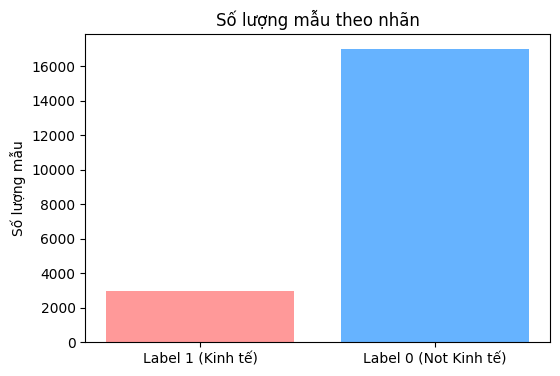

In [7]:
import matplotlib.pyplot as plt

# Dữ liệu cho biểu đồ
labels = ['Label 1 (Kinh tế)', 'Label 0 (Not Kinh tế)']
counts = [count_label_1, count_label_0]


# Biểu đồ cột
plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['#ff9999','#66b3ff'])
plt.ylabel('Số lượng mẫu')
plt.title('Số lượng mẫu theo nhãn')
plt.show()

### Pre-processing

In [8]:
texts = [item["title"] for item in sample_dataset]
texts

["Tuyệt phẩm Felicity Phu Quoc: 'Riêng đại dương, khung trời'",
 'Nghệ An: Đến 30.6, giải quyết hỗ trợ thuê trọ 178 lao động',
 'Sầu vụ giá cao, thị trường xuất khẩu khởi sắc',
 'Nam Định đầu thi THPT 2022 nước, Thanh Hóa 10',
 'Học sinh phổ thông hộ nghèo hỗ trợ máy bảng',
 'Hai vợ chồng nửa đêm bất ngờ tỉnh giấc xuất hiện "mùi lạ"',
 'Bắt giam chủ tịch xã cản trở công an cước công dân',
 'Cuộc biểu tình phủ tổng thống Sri Lanka thất thủ',
 'Những lệnh chả mua đầu tư tiền',
 'Indonesia đăng cai Asian Cup 2023, ĐT Việt Nam lo lắng độ?',
 'Cặp đôi quản lý - nhân viên kết hôn 1 Cát Tường mai',
 'TPHCM thu bao nhiêu tiền hủy đấu giá đất Thủ Thiêm 2 DN?',
 'Những hành động hài hước đỡ bao bật cười ngả nghiêng',
 'Người vợ "ông hoàng nhạc nghèo" Trường Vũ giấu kín suốt ai?',
 'Thu nhập shipper bao nhiêu tháng?',
 'Mùa sale kỳ lạ Trung Quốc',
 'U19 Việt Nam - U19 Indonesia: Quyết tâm giành chiến thắng',
 'Chiến thuật marketing cửa hàng tạp hóa, siêu thị đua hoa',
 'Mì liền Việt Nam cảnh báo 

In [9]:
texts = [text.lower() for text in texts]
texts

["tuyệt phẩm felicity phu quoc: 'riêng đại dương, khung trời'",
 'nghệ an: đến 30.6, giải quyết hỗ trợ thuê trọ 178 lao động',
 'sầu vụ giá cao, thị trường xuất khẩu khởi sắc',
 'nam định đầu thi thpt 2022 nước, thanh hóa 10',
 'học sinh phổ thông hộ nghèo hỗ trợ máy bảng',
 'hai vợ chồng nửa đêm bất ngờ tỉnh giấc xuất hiện "mùi lạ"',
 'bắt giam chủ tịch xã cản trở công an cước công dân',
 'cuộc biểu tình phủ tổng thống sri lanka thất thủ',
 'những lệnh chả mua đầu tư tiền',
 'indonesia đăng cai asian cup 2023, đt việt nam lo lắng độ?',
 'cặp đôi quản lý - nhân viên kết hôn 1 cát tường mai',
 'tphcm thu bao nhiêu tiền hủy đấu giá đất thủ thiêm 2 dn?',
 'những hành động hài hước đỡ bao bật cười ngả nghiêng',
 'người vợ "ông hoàng nhạc nghèo" trường vũ giấu kín suốt ai?',
 'thu nhập shipper bao nhiêu tháng?',
 'mùa sale kỳ lạ trung quốc',
 'u19 việt nam - u19 indonesia: quyết tâm giành chiến thắng',
 'chiến thuật marketing cửa hàng tạp hóa, siêu thị đua hoa',
 'mì liền việt nam cảnh báo 

In [10]:
texts_tokenized = [text.split() for text in texts]  
texts_tokenized

[['tuyệt',
  'phẩm',
  'felicity',
  'phu',
  'quoc:',
  "'riêng",
  'đại',
  'dương,',
  'khung',
  "trời'"],
 ['nghệ',
  'an:',
  'đến',
  '30.6,',
  'giải',
  'quyết',
  'hỗ',
  'trợ',
  'thuê',
  'trọ',
  '178',
  'lao',
  'động'],
 ['sầu', 'vụ', 'giá', 'cao,', 'thị', 'trường', 'xuất', 'khẩu', 'khởi', 'sắc'],
 ['nam', 'định', 'đầu', 'thi', 'thpt', '2022', 'nước,', 'thanh', 'hóa', '10'],
 ['học', 'sinh', 'phổ', 'thông', 'hộ', 'nghèo', 'hỗ', 'trợ', 'máy', 'bảng'],
 ['hai',
  'vợ',
  'chồng',
  'nửa',
  'đêm',
  'bất',
  'ngờ',
  'tỉnh',
  'giấc',
  'xuất',
  'hiện',
  '"mùi',
  'lạ"'],
 ['bắt',
  'giam',
  'chủ',
  'tịch',
  'xã',
  'cản',
  'trở',
  'công',
  'an',
  'cước',
  'công',
  'dân'],
 ['cuộc',
  'biểu',
  'tình',
  'phủ',
  'tổng',
  'thống',
  'sri',
  'lanka',
  'thất',
  'thủ'],
 ['những', 'lệnh', 'chả', 'mua', 'đầu', 'tư', 'tiền'],
 ['indonesia',
  'đăng',
  'cai',
  'asian',
  'cup',
  '2023,',
  'đt',
  'việt',
  'nam',
  'lo',
  'lắng',
  'độ?'],
 ['cặp',
  'đôi',


In [11]:
vietnamese_stopwords = set([
    'bị', 'bởi', 'cả', 'các', 'cái', 'cần', 'càng', 'chỉ', 'chiếc',
    'cho', 'chứ', 'chưa', 'chuyện', 'có', 'có_thể', 'cứ', 'của', 'cùng',
    'cũng', 'đã', 'đang', 'đây', 'để', 'đến_nỗi', 'đều', 'điều', 'do',
    'đó', 'được', 'dưới', 'gì', 'khi', 'không', 'là', 'lại', 'lên', 'lúc',
    'mà', 'mỗi', 'một_cách', 'này', 'nên', 'nếu', 'ngay', 'nhiều', 'như',
    'nhưng', 'những', 'nơi', 'nữa', 'phải', 'qua', 'ra', 'rằng', 'rất',
    'rồi', 'sau', 'sẽ', 'so', 'sự', 'tại', 'theo', 'thì', 'trên', 'trước',
    'từ', 'từng', 'và', 'vẫn', 'vào', 'vậy', 'vì', 'việc', 'với', 'vừa'
])



# Loại bỏ stopwords
texts_tokenized = [
    [word for word in text if word not in vietnamese_stopwords]
    for text in texts_tokenized
]

texts_tokenized

[['tuyệt',
  'phẩm',
  'felicity',
  'phu',
  'quoc:',
  "'riêng",
  'đại',
  'dương,',
  'khung',
  "trời'"],
 ['nghệ',
  'an:',
  'đến',
  '30.6,',
  'giải',
  'quyết',
  'hỗ',
  'trợ',
  'thuê',
  'trọ',
  '178',
  'lao',
  'động'],
 ['sầu', 'vụ', 'giá', 'cao,', 'thị', 'trường', 'xuất', 'khẩu', 'khởi', 'sắc'],
 ['nam', 'định', 'đầu', 'thi', 'thpt', '2022', 'nước,', 'thanh', 'hóa', '10'],
 ['học', 'sinh', 'phổ', 'thông', 'hộ', 'nghèo', 'hỗ', 'trợ', 'máy', 'bảng'],
 ['hai',
  'vợ',
  'chồng',
  'nửa',
  'đêm',
  'bất',
  'ngờ',
  'tỉnh',
  'giấc',
  'xuất',
  'hiện',
  '"mùi',
  'lạ"'],
 ['bắt',
  'giam',
  'chủ',
  'tịch',
  'xã',
  'cản',
  'trở',
  'công',
  'an',
  'cước',
  'công',
  'dân'],
 ['cuộc',
  'biểu',
  'tình',
  'phủ',
  'tổng',
  'thống',
  'sri',
  'lanka',
  'thất',
  'thủ'],
 ['lệnh', 'chả', 'mua', 'đầu', 'tư', 'tiền'],
 ['indonesia',
  'đăng',
  'cai',
  'asian',
  'cup',
  '2023,',
  'đt',
  'việt',
  'nam',
  'lo',
  'lắng',
  'độ?'],
 ['cặp',
  'đôi',
  'quản',

In [12]:
texts_clean = [' '.join(text) for text in texts_tokenized]
texts_clean

["tuyệt phẩm felicity phu quoc: 'riêng đại dương, khung trời'",
 'nghệ an: đến 30.6, giải quyết hỗ trợ thuê trọ 178 lao động',
 'sầu vụ giá cao, thị trường xuất khẩu khởi sắc',
 'nam định đầu thi thpt 2022 nước, thanh hóa 10',
 'học sinh phổ thông hộ nghèo hỗ trợ máy bảng',
 'hai vợ chồng nửa đêm bất ngờ tỉnh giấc xuất hiện "mùi lạ"',
 'bắt giam chủ tịch xã cản trở công an cước công dân',
 'cuộc biểu tình phủ tổng thống sri lanka thất thủ',
 'lệnh chả mua đầu tư tiền',
 'indonesia đăng cai asian cup 2023, đt việt nam lo lắng độ?',
 'cặp đôi quản lý - nhân viên kết hôn 1 cát tường mai',
 'tphcm thu bao nhiêu tiền hủy đấu giá đất thủ thiêm 2 dn?',
 'hành động hài hước đỡ bao bật cười ngả nghiêng',
 'người vợ "ông hoàng nhạc nghèo" trường vũ giấu kín suốt ai?',
 'thu nhập shipper bao nhiêu tháng?',
 'mùa sale kỳ lạ trung quốc',
 'u19 việt nam - u19 indonesia: quyết tâm giành chiến thắng',
 'chiến thuật marketing cửa hàng tạp hóa, siêu thị đua hoa',
 'mì liền việt nam cảnh báo eu',
 'huế: 

### Split data for train

In [13]:
texts = texts_clean
label = [i["label"] for i in sample_dataset]

print(texts[8])
print(label[8])
print(len(texts))
print(len(label))

lệnh chả mua đầu tư tiền
1
20000
20000


In [46]:
# from sklearn.model_selection import train_test_split

# #70% train
# #15% validation
# #15% test

# # Bước 1: tách train và temp (val + test)
# X_train, X_temp, y_train, y_temp = train_test_split(
#     texts, label,
#     test_size=0.3,
#     random_state=42,
#     stratify=label
# )

# # Bước 2: tách validation và test
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.5,
#     random_state=42,
#     stratify=y_temp
# )

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    texts, label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

import numpy as np

y_train = np.array(y_train)
y_test = np.array(y_test)

print(len(X_train))
print( len(X_test))
print(len(y_train))
print(len(y_test))
print(sum(y_test == 0), sum(y_test == 1))

16000
4000
16000
4000
3400 600


### Vectorizer

In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [16]:
def evaluate_and_print(model_name, vectorizer_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"=== Model: {model_name} | Vectorizer: {vectorizer_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\n")

### BoW + Naive Bayes

In [27]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
vectorizers = {
    "Bow": CountVectorizer(),
    "TF-IDF": TfidfVectorizer()
}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "SVM": SVC(kernel="linear")
}

In [19]:
# results = []
# for vec_name, vectorizer in vectorizers.items():
#     X_train_vec = vectorizer.fit_transform(X_train)

#     X_val_vec = vectorizer.transform(X_val)
#     X_test_vec = vectorizer.transform(X_test)

#     for model_name, model in models.items():
#         #train
#         model.fit(X_train_vec, y_train)

#         #validation
#         y_val_pred = model.predict(X_val_vec)
#         print(">>>>>>>>>>>>>>> VALIDATION <<<<<<<<<<<<<<<")
#         evaluate_and_print(model_name, vec_name, y_val, y_val_pred)

#         # luu ket qua de chon model tot nhat
#         f1_val = f1_val = f1_score(y_val, y_val_pred, pos_label=1, zero_division=0)
#         results.append((vec_name, model_name, model, vectorizer, f1_val))

NameError: name 'X_val' is not defined

In [48]:
# best = sorted(results, key=lambda x: x[4], reverse=True)[0]

# best_vec_name, best_model_name, best_model, best_vectorizer, _ = best

# print(f"Best model: {best_model_name} | {best_vec_name}")

Best model: SVM | Bow


In [49]:
# # Transform lại test bằng vectorizer tốt nhất
# X_test_vec = best_vectorizer.transform(X_test)

# y_test_pred = best_model.predict(X_test_vec)

# print(">>> FINAL TEST")
# evaluate_and_print(best_model_name, best_vec_name, y_test, y_test_pred)

# >>>>>>>>>>>>>>> VALIDATION <<<<<<<<<<<<<<<
# === Model: SVM | Vectorizer: Bow ===
# Accuracy : 0.8833
# Precision: 0.6667
# Recall   : 0.4444
# F1-score : 0.5333
# Confusion Matrix:
# [[245  10]
#  [ 25  20]]

>>> FINAL TEST
=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.8233
Precision: 0.4429
Recall   : 0.6889
F1-score : 0.5391
Confusion Matrix:
[[216  39]
 [ 14  31]]




=== Model: Naive Bayes | Vectorizer: Bow ===
Accuracy : 0.9040
Precision: 0.6770
Recall   : 0.6883
F1-score : 0.6826
Confusion Matrix:
[[3203  197]
 [ 187  413]]




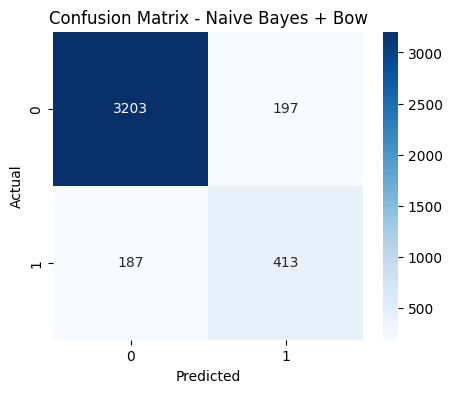

=== Model: Logistic Regression | Vectorizer: Bow ===
Accuracy : 0.9067
Precision: 0.7293
Recall   : 0.6017
F1-score : 0.6594
Confusion Matrix:
[[3266  134]
 [ 239  361]]




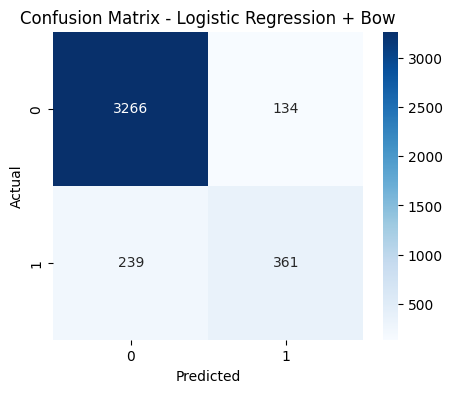

=== Model: SVM | Vectorizer: Bow ===
Accuracy : 0.8985
Precision: 0.6690
Recall   : 0.6400
F1-score : 0.6542
Confusion Matrix:
[[3210  190]
 [ 216  384]]




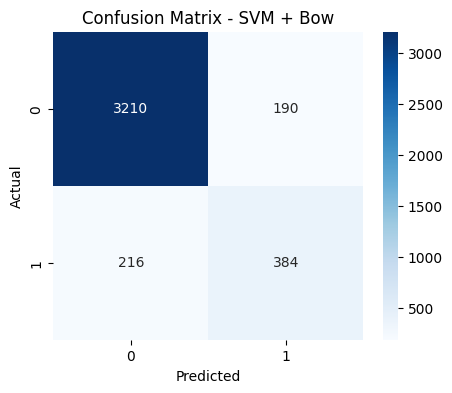

=== Model: Naive Bayes | Vectorizer: TF-IDF ===
Accuracy : 0.8865
Precision: 0.9148
Recall   : 0.2683
F1-score : 0.4149
Confusion Matrix:
[[3385   15]
 [ 439  161]]




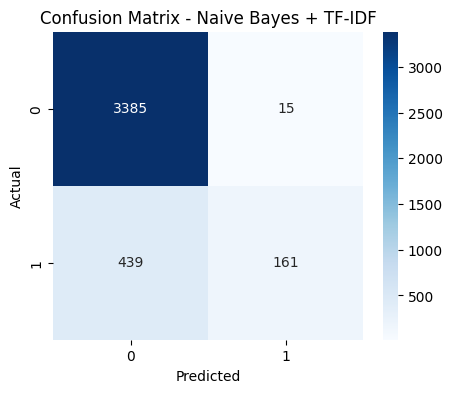

=== Model: Logistic Regression | Vectorizer: TF-IDF ===
Accuracy : 0.9085
Precision: 0.8047
Recall   : 0.5150
F1-score : 0.6280
Confusion Matrix:
[[3325   75]
 [ 291  309]]




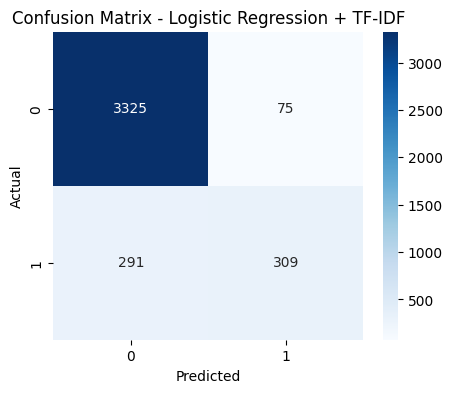

=== Model: SVM | Vectorizer: TF-IDF ===
Accuracy : 0.9105
Precision: 0.7574
Recall   : 0.5933
F1-score : 0.6654
Confusion Matrix:
[[3286  114]
 [ 244  356]]




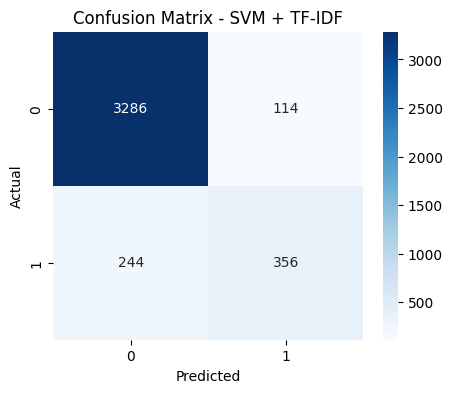

In [45]:
results = []
for vec_name, vectorizer in vectorizers.items():
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    for model_name, model in models.items():
        #train
        model.fit(X_train_vec, y_train)

        #prediction
        y_pred = model.predict(X_test_vec)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        evaluate_and_print(model_name, vec_name, y_test, y_pred)

         # confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name} + {vec_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
        
        
        results.append({
            "vectorizer": vec_name,
            "model": model_name,
            "accuracy": acc,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "cm": cm
        })

In [46]:
best_acc = max(results, key=lambda x: x['accuracy'])
print("Best accuracy:")
print(f"Vectorizer: {best_acc['vectorizer']}")
print(f"Model: {best_acc['model']}")
print(f"Accuracy: {best_acc['accuracy']:.4f}")

Best accuracy:
Vectorizer: TF-IDF
Model: SVM
Accuracy: 0.9105


In [50]:
best_f1_label1 = max(results, key=lambda x: x['f1'])
print("Best model for class 1 (Kinh tế/Kinh doanh):")
print(f"Vectorizer: {best_f1_label1['vectorizer']}")
print(f"Model: {best_f1_label1['model']}")
print(f"Accuracy: {best_f1_label1['accuracy']:.4f}")
print(f"Precision: {best_f1_label1['precision']:.4f}")
print(f"Recall: {best_f1_label1['recall']:.4f}")
print(f"F1: {best_f1_label1['f1']:.4f}")


Best model for class 1 (Kinh tế/Kinh doanh):
Vectorizer: Bow
Model: Naive Bayes
Accuracy: 0.9040
Precision: 0.6770
Recall: 0.6883
F1: 0.6826
